In [10]:
from langgraph.graph import StateGraph
from typing import TypedDict

In [11]:
class AgentState(TypedDict):
    name:str
    age:int
    final:str
    

In [12]:
def first_node(state:AgentState) ->AgentState:
    """This is the first node of our sequence"""

    state["final"] = f"Hi {state["name"]}"

    return state

def second_node(state:AgentState) -> AgentState:
    "This s the second node of our sequence"

    state["final"] = state["final"] + f"you are {state["age"]} years old"

    return state

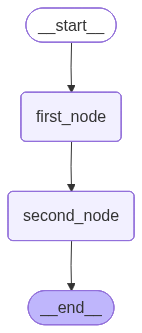

In [13]:
graph = StateGraph(AgentState)

graph.add_node("first_node",first_node)
graph.add_node("second_node",second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")

graph.set_finish_point("second_node")



app = graph.compile()

app

In [14]:
app.invoke({"name":"josh","age":29})

{'name': 'josh', 'age': 29, 'final': 'Hi joshyou are 29 years old'}

Your tassk:

1. Accept user input
2. Having three nodes,one for name, age and last for skills

In [15]:
from typing import List,TypedDict
from langgraph.graph import StateGraph

In [16]:
class AgentState(TypedDict):
    name:str
    age:str
    skills:List[str]
    output:str


In [34]:
def first_node(state:AgentState) -> AgentState:
    state["output"] = f"Hi, {state["name"]}"

    return state

def second_node(state:AgentState) ->AgentState:
    state["output"] = state["output"] + f"You are {state["age"]} years old"

    return state

def final_node(state:AgentState) -> AgentState:
    state["output"] = state["output"] + f"You are good at {state["skills"]} "

    return state

    


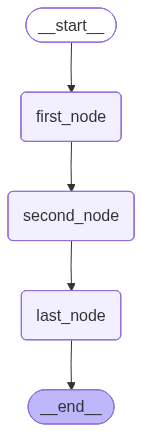

In [35]:
graph = StateGraph(AgentState)


graph.add_node("first_node",first_node)
graph.add_node("second_node",second_node)
graph.add_node("last_node",final_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.add_edge("second_node","last_node")


graph.set_finish_point("last_node")

app = graph.compile()

app



In [36]:
answer = app.invoke({"name":"Josh","age":34,"skills":["Python","Machine Learning","Langchain"]})

In [37]:
answer["output"]

"Hi, JoshYou are 34 years oldYou are good at ['Python', 'Machine Learning', 'Langchain'] "